In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('../data/raw/complaints.csv') # Adjust path as needed

credi_trust_mapping = {
    # 1. Credit Cards
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Prepaid card': 'Credit Card',
    
    # 2. Savings Accounts
    'Checking or savings account': 'Savings Account',
    'Bank account or service': 'Savings Account',
    
    # 3. Money Transfers
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
    'Virtual currency': 'Money Transfer',
    
    # 4. Personal Loans
    'Payday loan, title loan, personal loan, or advance loan': 'Personal Loan',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Consumer Loan': 'Personal Loan',
    'Payday loan': 'Personal Loan'
}


# 1. Filter using the keys from  mapping
df_final = df[df['Product'].isin(credi_trust_mapping.keys())].copy()

# Create the new unified column
df_final['Product_Category'] = df_final['Product'].map(credi_trust_mapping)

# Drop rows where there is no story (narrative)
df_final = df_final.dropna(subset=['Consumer complaint narrative'])

print("Data successfully grouped!")
print(df_final['Product_Category'].value_counts())
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'x{2,}', '', text)  # Removes XXXX
    text = re.sub(r'[^a-z0-9\s]', '', text) # Removes special characters
    return text.strip()

df_final['cleaned_narrative'] = df_final['Consumer complaint narrative'].apply(clean_text)

# Save for Task 2
df_final.to_csv('../data/processed/filtered_complaints.csv', index=False)

C:\Users\DELL 7020\AppData\Local\Temp\ipykernel_14532\1190024981.py:6: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/complaints.csv') # Adjust path as needed


Data successfully grouped!
Product_Category
Credit Card        197126
Savings Account    155204
Money Transfer      98701
Personal Loan       37341
Name: count, dtype: int64


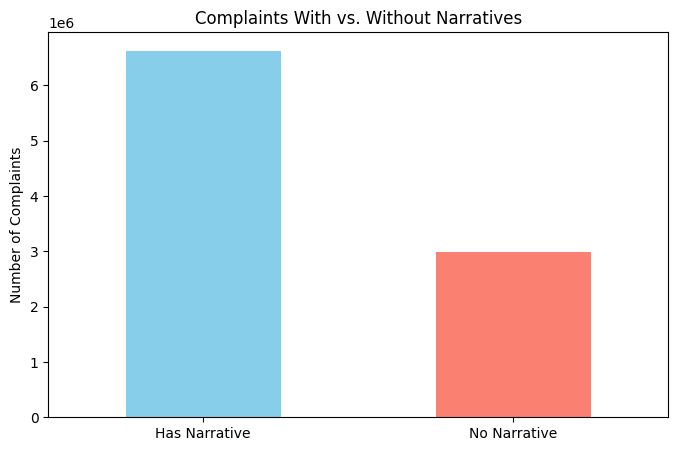

Total Complaints: 9,609,797
Complaints with Narratives: 6,629,041
Percentage: 68.98%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count missing vs present narratives
missing_narratives = df['Consumer complaint narrative'].isnull().value_counts()
# Note: isnull().value_counts() returns False for "has text" and True for "is null"

missing_narratives.index = ['Has Narrative', 'No Narrative']

# Plot
plt.figure(figsize=(8, 5))
missing_narratives.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Complaints With vs. Without Narratives')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=0)
plt.show()

has_narrative_count = missing_narratives['Has Narrative']
total_count = len(df)
percentage = (has_narrative_count / total_count) * 100

print(f"Total Complaints: {total_count:,}")
print(f"Complaints with Narratives: {has_narrative_count:,}")
print(f"Percentage: {percentage:.2f}%")

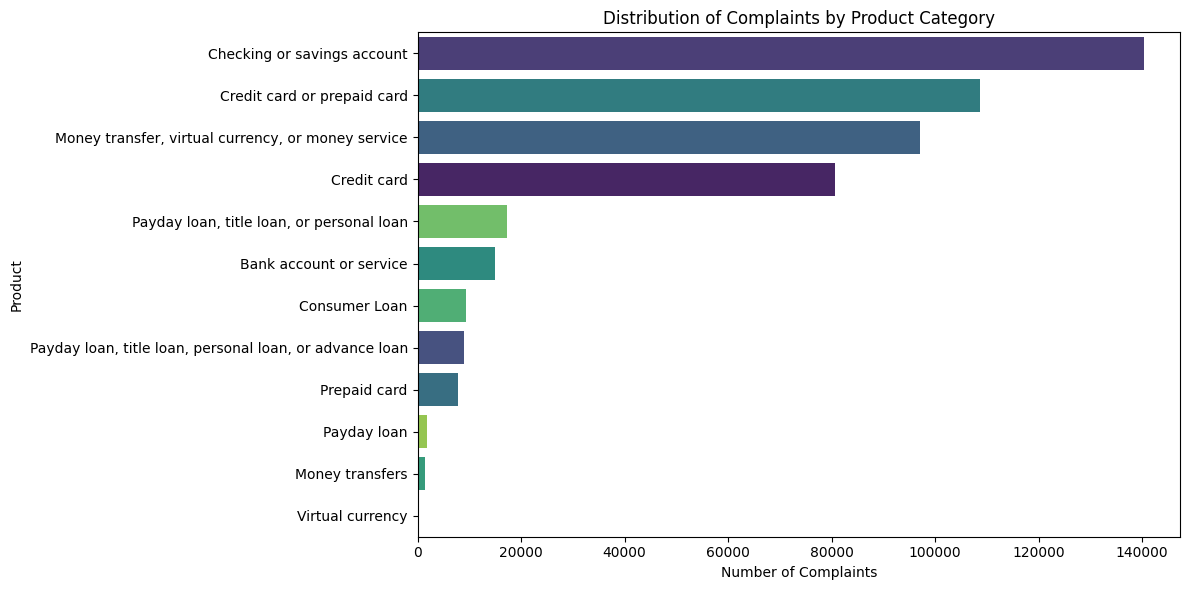

Complaints per product:
<StringArray>
[                                            'Credit card',
                             'Checking or savings account',
 'Payday loan, title loan, personal loan, or advance loan',
      'Money transfer, virtual currency, or money service',
                                            'Prepaid card',
                             'Credit card or prepaid card',
                                 'Bank account or service',
                                         'Money transfers',
                                           'Consumer Loan',
               'Payday loan, title loan, or personal loan',
                                             'Payday loan',
                                        'Virtual currency']
Length: 12, dtype: str


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_final, y='Product', order=df_final['Product'].value_counts().index, hue='Product', palette='viridis', legend=False)
plt.title('Distribution of Complaints by Product Category')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

print("Complaints per product:")
print(df_final['Product'].unique())

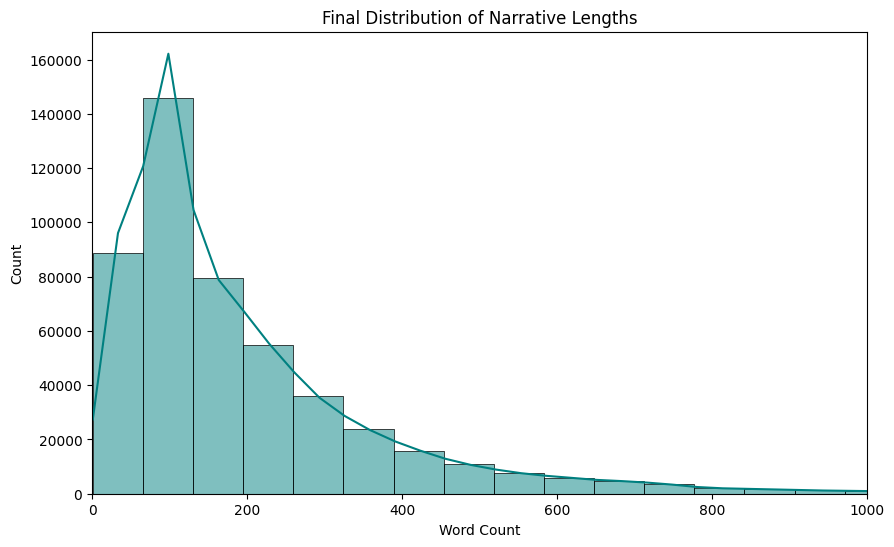

Average words: 205.1


In [13]:
# Calculate word count
df_final['word_count'] = df_final['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_final['word_count'], bins=100, kde=True, color='teal')
plt.title('Final Distribution of Narrative Lengths')
plt.xlabel('Word Count')
plt.xlim(0, 1000) 
plt.show()

print(f"Average words: {df_final['word_count'].mean():.1f}")